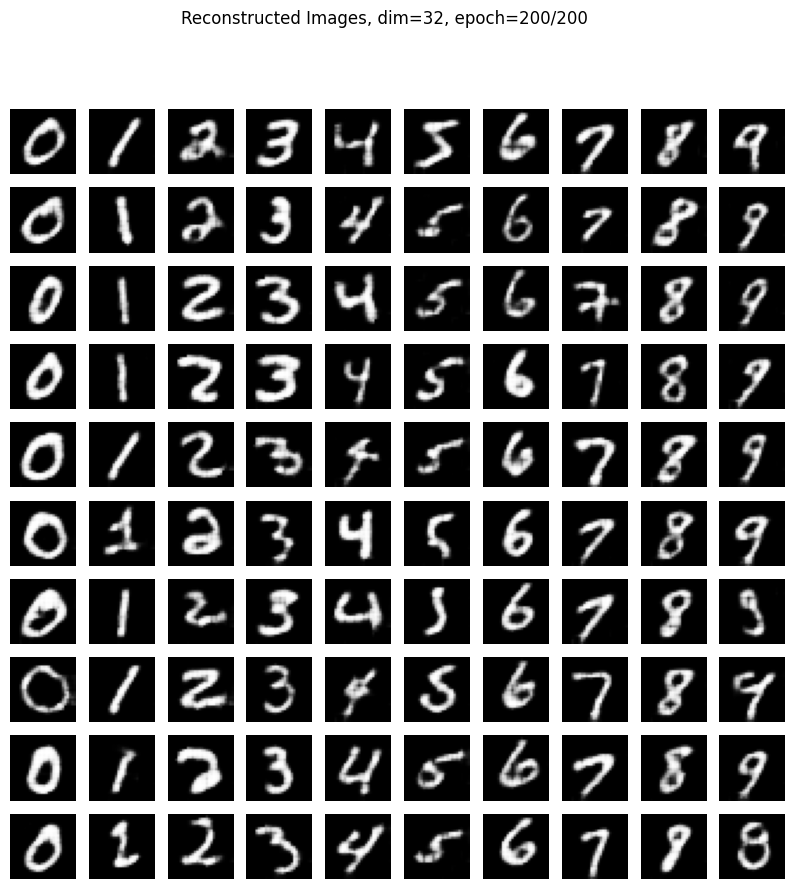

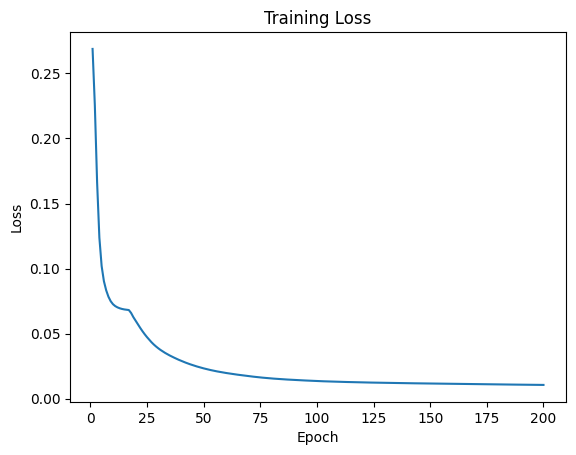

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import importlib

from modules import Autoencoder
importlib.reload(Autoencoder)  # 모듈 갱신
from IPython.display import clear_output

latent_dim = 32
epochs = 200
lr = 0.00003

# 모델 초기화
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
optimizer = optim.Adam(autoencoder.parameters(), lr=lr)
criterion = nn.MSELoss()

# 데이터 로더 설정
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# 오토인코더 학습
losses = []
for epoch in range(epochs):
    epoch_loss = 0  # 에포크별 손실 초기화
    batch_count = 0
    for images, _ in train_loader:
        images = images.view(-1, 1, 28, 28)
        optimizer.zero_grad()
        reconstructed = autoencoder(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        batch_count += 1
    
    # 새 epoch마다 출력 클리어
    clear_output(wait=True)
    
    # 0~9 숫자별로 10개씩 이미지 선택
    images_by_digit = {i: [] for i in range(10)}
    for img, label in train_data:
        if len(images_by_digit[label]) < 10:
            images_by_digit[label].append(img)
        if all(len(images) == 10 for images in images_by_digit.values()):
            break

    # 이미지 복원
    reconstructed_images = []
    for digit in range(10):
        images = torch.stack(images_by_digit[digit])  # 10개의 숫자 이미지
        reconstructed = autoencoder(images).detach()  # 복원된 이미지
        reconstructed_images.append(reconstructed)

    # 10x10 그리드에 시각화
    fig, axs = plt.subplots(10, 10, figsize=(10, 10))
    for i in range(10):
        for j in range(10):
            axs[j, i].imshow(reconstructed_images[i][j].view(28, 28).numpy(), cmap='gray')
            axs[j, i].axis('off')
    
    plt.suptitle(f"Reconstructed Images, dim={latent_dim}, epoch={epoch + 1}/{epochs}")
    plt.show()

    # 그동안의 손실 전부 출력
    losses.append(epoch_loss / batch_count)
    plt.plot(range(1, len(losses) + 1), losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

In [5]:
# save & load autoencoder
save = True
load = False
if save:
    torch.save(autoencoder.state_dict(), f'savepoints/autoencoder_{latent_dim}_ep{epochs}_lr{lr}.pth')
if load:
    autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
    autoencoder.load_state_dict(torch.load('savepoints/autoencoder.pth'))

In [ ]:
import numpy as np
import random
import torch
from torchvision import datasets, transforms

# MNIST 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 클래스별로 2000개의 이미지를 랜덤하게 추출하여 저장할 딕셔너리 초기화
num_images_per_class = 2000
data_dict = {}

for digit in range(10):
    # 해당 클래스의 이미지 필터링
    images_for_class = [img for img, label in train_data if label == digit]
    print("Number of images for digit", digit, ":", len(images_for_class))
    
    # 랜덤하게 2000개의 이미지 선택
    selected_images = random.sample(images_for_class, num_images_per_class)
    
    # 원본 이미지와 latent 값 저장할 리스트
    original_images = []
    latent_vectors = []
    
    # 각 이미지를 처리하여 원본 이미지와 latent 값 추출
    for img in selected_images:
        img = img.unsqueeze(0)  # 차원 맞추기 (1, 1, 28, 28)
        original_images.append(img.numpy())  # 원본 이미지 저장
        
        # 오토인코더를 통해 latent 벡터 추출
        with torch.no_grad():
            latent_vector = autoencoder.encoder(img).numpy()
            latent_vectors.append(latent_vector)

    # numpy 배열로 변환
    original_images = np.array(original_images).squeeze()  # (2000, 28, 28)
    latent_vectors = np.array(latent_vectors).squeeze()    # (2000, latent_dim)
    print(latent_vectors.shape, latent_vectors.max(), latent_vectors.min())
    
    # data_dict에 저장
    data_dict[f'{digit}_raw'] = original_images
    data_dict[f'{digit}_latent'] = latent_vectors

# 모든 데이터를 하나의 npz 파일에 저장
import os
if not os.path.exists(f'./data/MNIST/{latent_dim}_{epoch}_{lr}'):
    os.makedirs(f'./data/MNIST/{latent_dim}_{epoch}_{lr}')
np.savez(f'./data/MNIST/{latent_dim}_{epoch}_{lr}/mnist_{latent_dim}_{num_images_per_class}.npz', **data_dict)

print("Data saved successfully.")


Number of images for digit 0 : 5923
(2000, 32) 0.06058022 0.0077499887
Number of images for digit 1 : 6742
(2000, 32) 0.06145728 0.008253938
Number of images for digit 2 : 5958
(2000, 32) 0.061517753 0.007615348
Number of images for digit 3 : 6131
(2000, 32) 0.059524104 0.007619089
Number of images for digit 4 : 5842
(2000, 32) 0.059785046 0.007692686
Number of images for digit 5 : 5421
(2000, 32) 0.059756283 0.007593256
Number of images for digit 6 : 5918
(2000, 32) 0.06013568 0.007758581
Number of images for digit 7 : 6265
(2000, 32) 0.0614629 0.0076418095
Number of images for digit 8 : 5851
(2000, 32) 0.059725624 0.007479756
Number of images for digit 9 : 5949
(2000, 32) 0.05878053 0.00760355
Data saved successfully.


: 